In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the Excel file
data = pd.read_csv('data/clean_air_quality.csv')

data.head()

,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,NO2(GT)
0,1360.00,1045.50,1056.25,1692.00,1267.50,13.60,48.875001,0.757754,113.0
1,1292.25,954.75,1173.75,1558.75,972.25,13.30,47.700000,0.725487,92.0
2,1402.00,939.25,1140.00,1554.50,1074.00,11.90,53.975000,0.750239,114.0
3,1375.50,948.25,1092.00,1583.75,1203.25,11.00,60.000000,0.786713,122.0
4,1272.25,835.50,1205.00,1490.00,1110.00,11.15,59.575001,0.788794,116.0


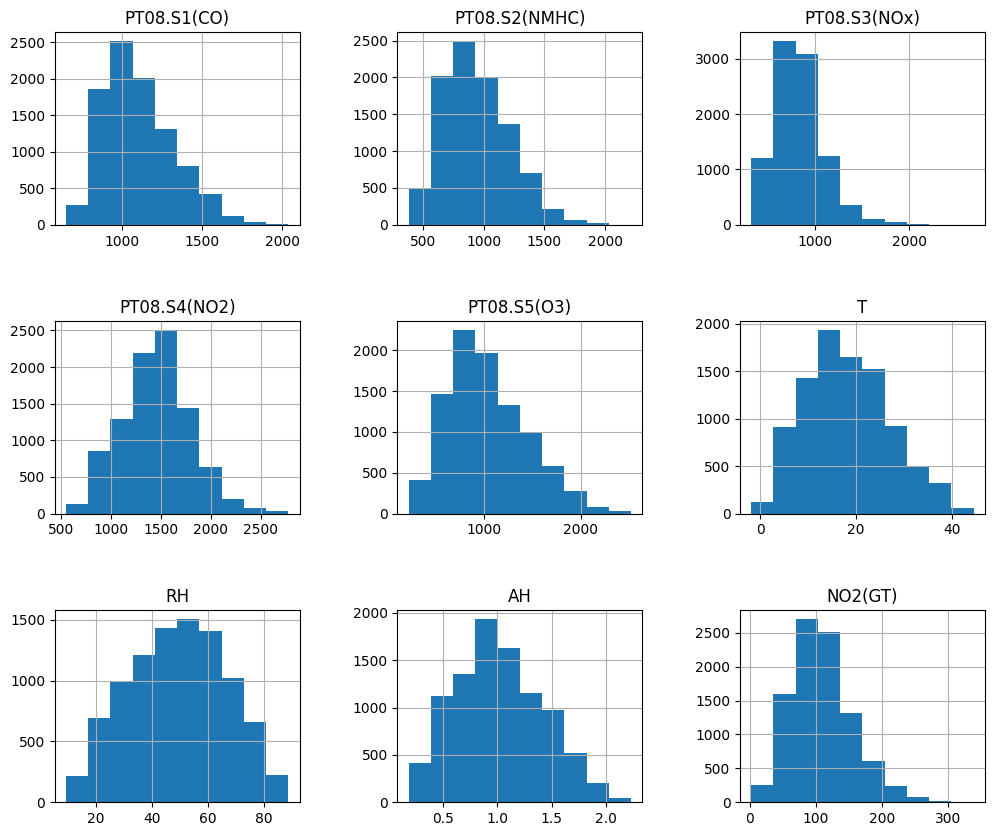

In [3]:
data.hist(figsize=(12, 10))
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()

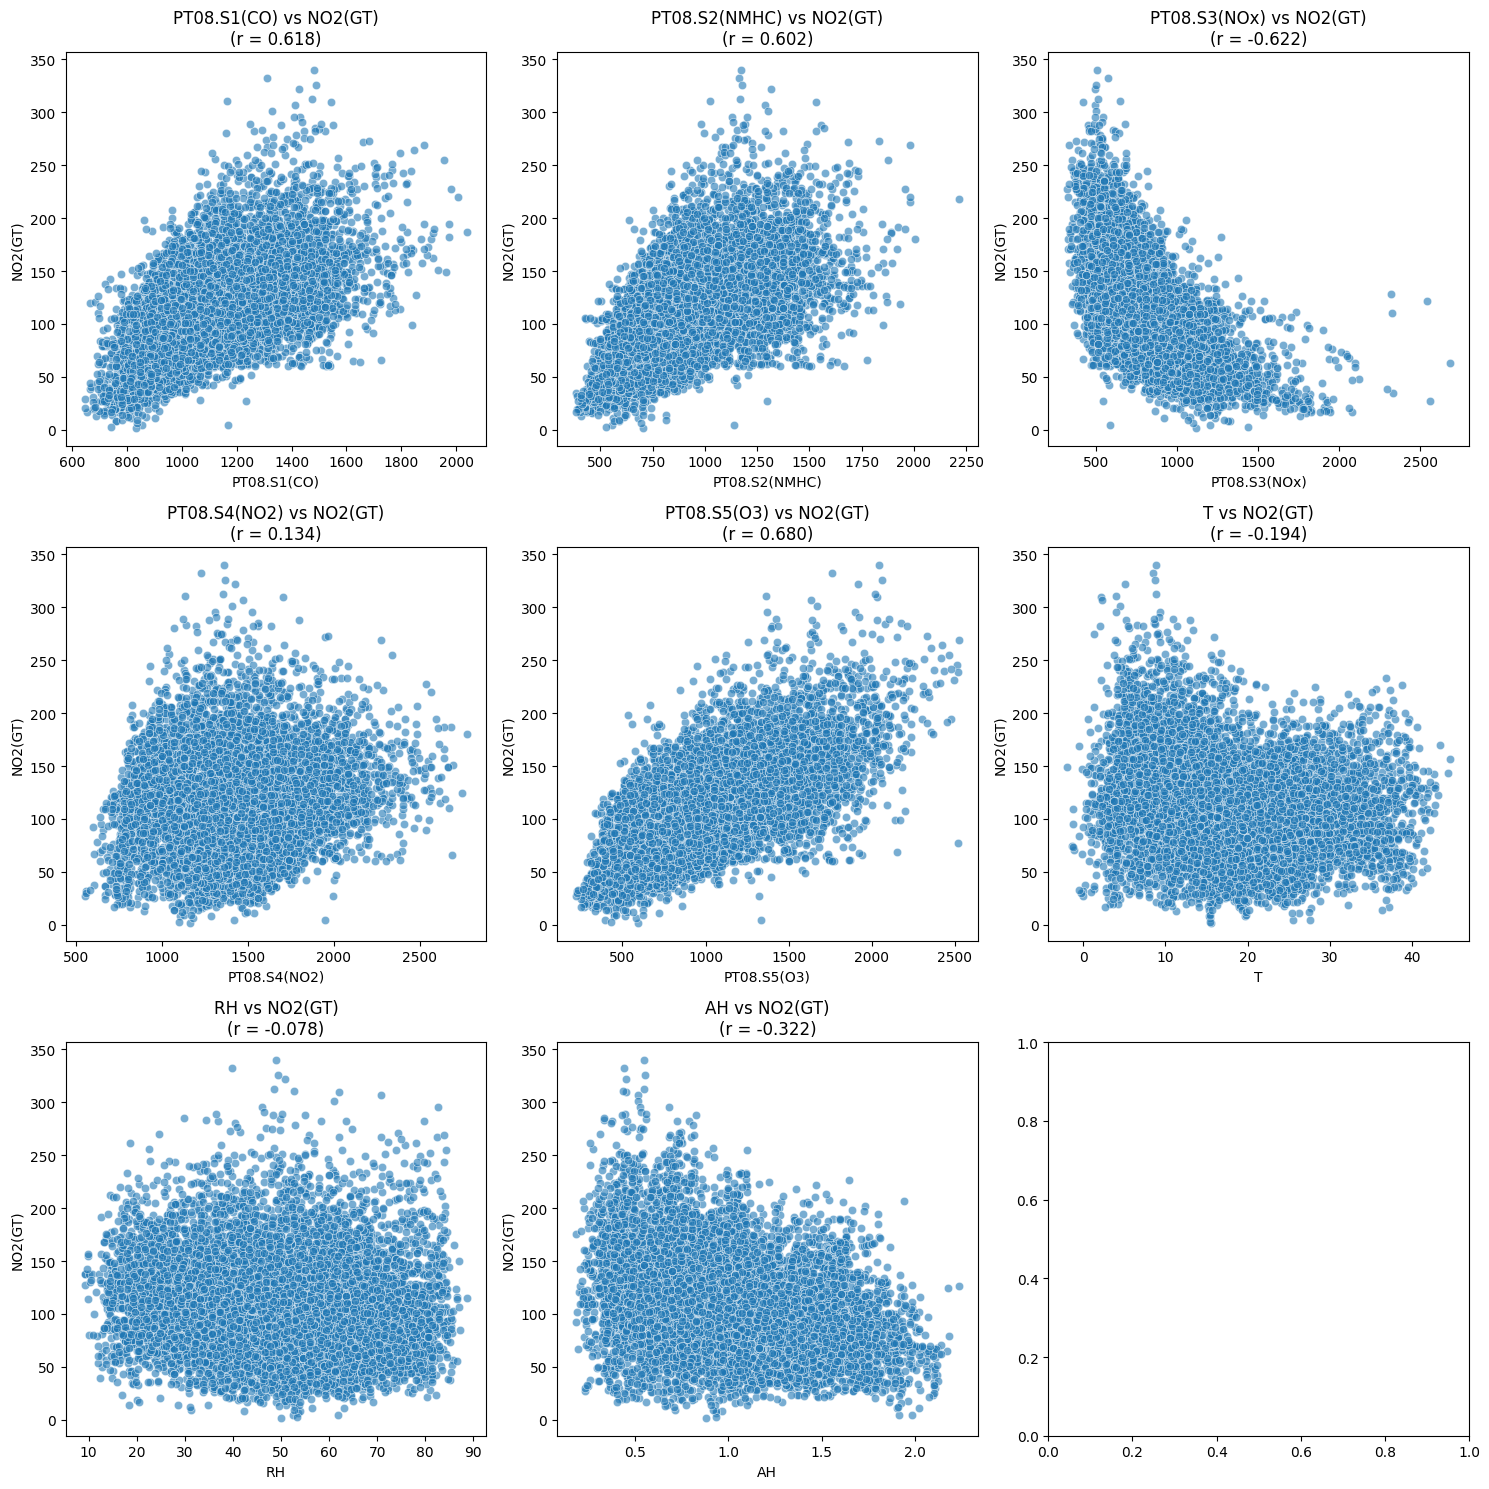

In [7]:
X = data[['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']]
y = data['NO2(GT)']

# Calculate grid dimensions
n_features = len(X.columns)
n_cols = 3  # Number of columns in the grid
n_rows = (n_features + n_cols - 1) // n_cols  # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for i, col in enumerate(X.columns):
    sns.scatterplot(x=X[col], y=y, alpha=0.6, ax=axes[i])
    corr_value = X[col].corr(y)
    axes[i].set_title(f"{col} vs {y.name}\n(r = {corr_value:.3f})")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(y.name)

plt.tight_layout()
plt.show()

### EDA Findings

PT08.S3(NOx); Strong negative, nonlinear (r = -0.622)

Decreasing and concave upward.

Add quadratic and log(x)

In [27]:
data['PT08.S3(NOx)_sq'] = data['PT08.S3(NOx)']**2
data['PT08.S3(NOx)_log'] = np.log(data['PT08.S3(NOx)'] + 1)

Temperature (T); Slight negative, nonlinear (r = -0.194)

Looks inverted bell-shaped: maybe parabola-like.

Add quadratic

In [28]:
data['T_sq'] = data['T']**2

AH (Absolute Humidity); Moderate negative (r = -0.322)

Clear trend, flattens out. Looks logarithmic or square root-ish.

log(AH + ε)


In [29]:
data['AH_log'] = np.log(data['AH'] + 1e-5)  # to avoid log(0)

The effect of temperature on air quality might be amplified when humidity is high.

In [30]:
data['T_RH'] = data['T'] * data['RH']

In [31]:
data.head()

,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,NO2(GT),PT08.S3(NOx)_sq,T_sq,AH_log,T_RH,PT08.S3(NOx)_log
0,1360.00,1045.50,1056.25,1692.00,1267.50,13.60,48.875001,0.757754,113.0,1.115664e+06,184.959997,-0.277384,664.700008,6.963426
1,1292.25,954.75,1173.75,1558.75,972.25,13.30,47.700000,0.725487,92.0,1.377689e+06,176.889999,-0.320898,634.409995,7.068811
2,1402.00,939.25,1140.00,1554.50,1074.00,11.90,53.975000,0.750239,114.0,1.299600e+06,141.610002,-0.287350,642.302510,7.039660
3,1375.50,948.25,1092.00,1583.75,1203.25,11.00,60.000000,0.786713,122.0,1.192464e+06,121.000000,-0.239880,660.000000,6.996681
4,1272.25,835.50,1205.00,1490.00,1110.00,11.15,59.575001,0.788794,116.0,1.452025e+06,124.322502,-0.237237,664.261264,7.095064


In [32]:
data.to_csv("data/clean_engineered_air_quality.csv", index=False)

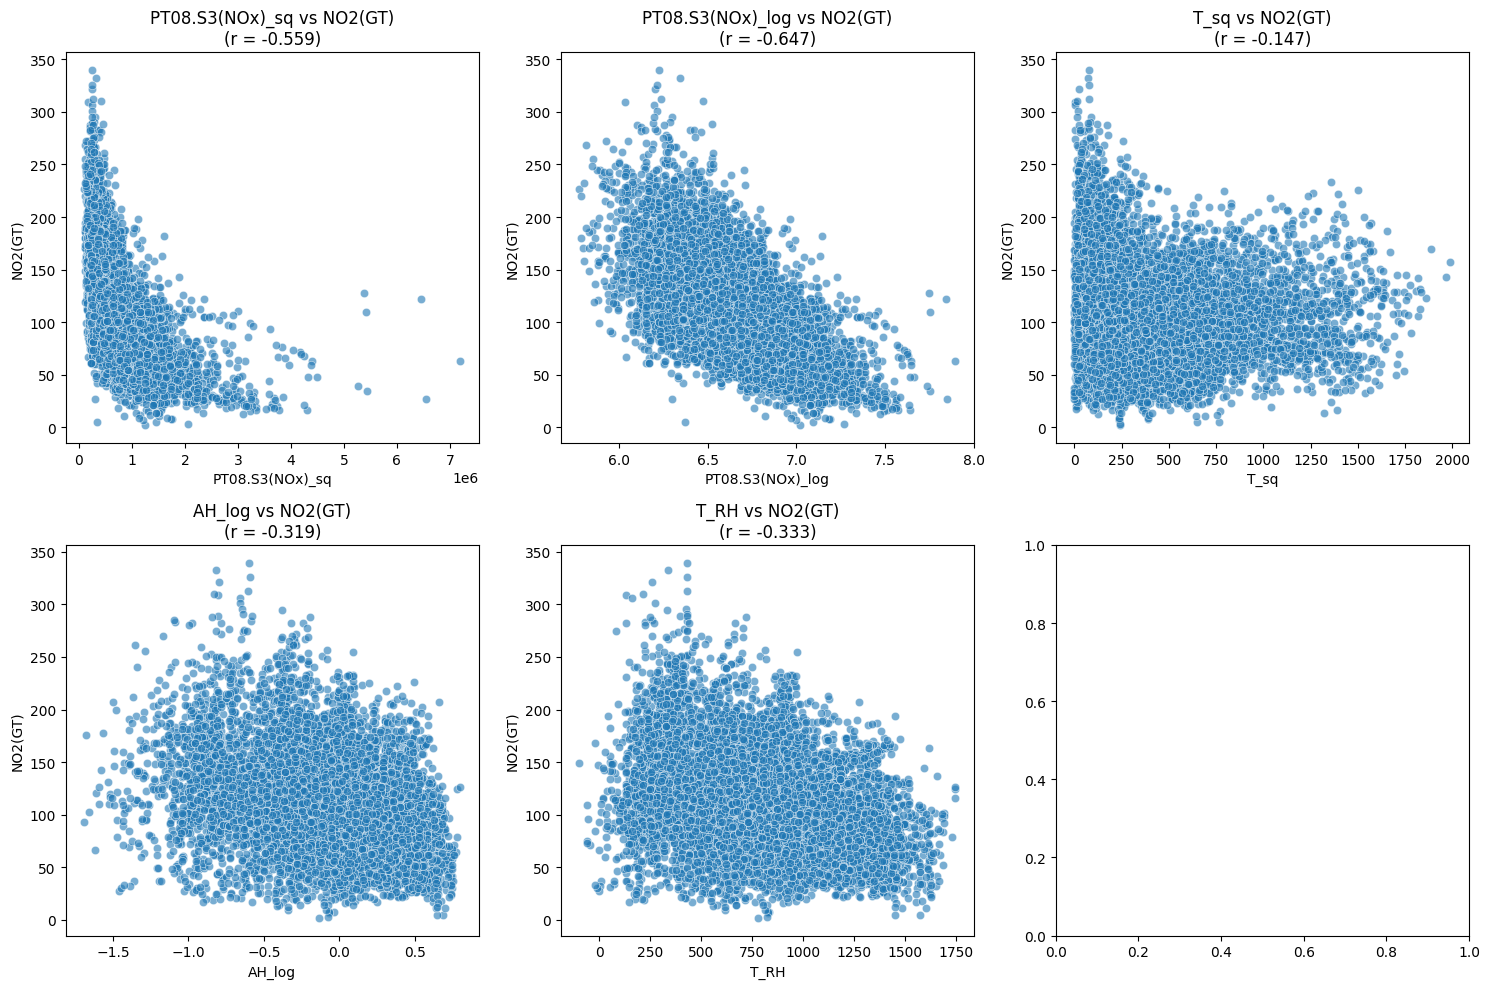

In [33]:
X = data[['PT08.S3(NOx)_sq', 'PT08.S3(NOx)_log', 'T_sq', 'AH_log', 'T_RH']]
y = data['NO2(GT)']

# Calculate grid dimensions
n_features = len(X.columns)
n_cols = 3  # Number of columns in the grid
n_rows = (n_features + n_cols - 1) // n_cols  # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for i, col in enumerate(X.columns):
    sns.scatterplot(x=X[col], y=y, alpha=0.6, ax=axes[i])
    corr_value = X[col].corr(y)
    axes[i].set_title(f"{col} vs {y.name}\n(r = {corr_value:.3f})")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(y.name)

plt.tight_layout()
plt.show()

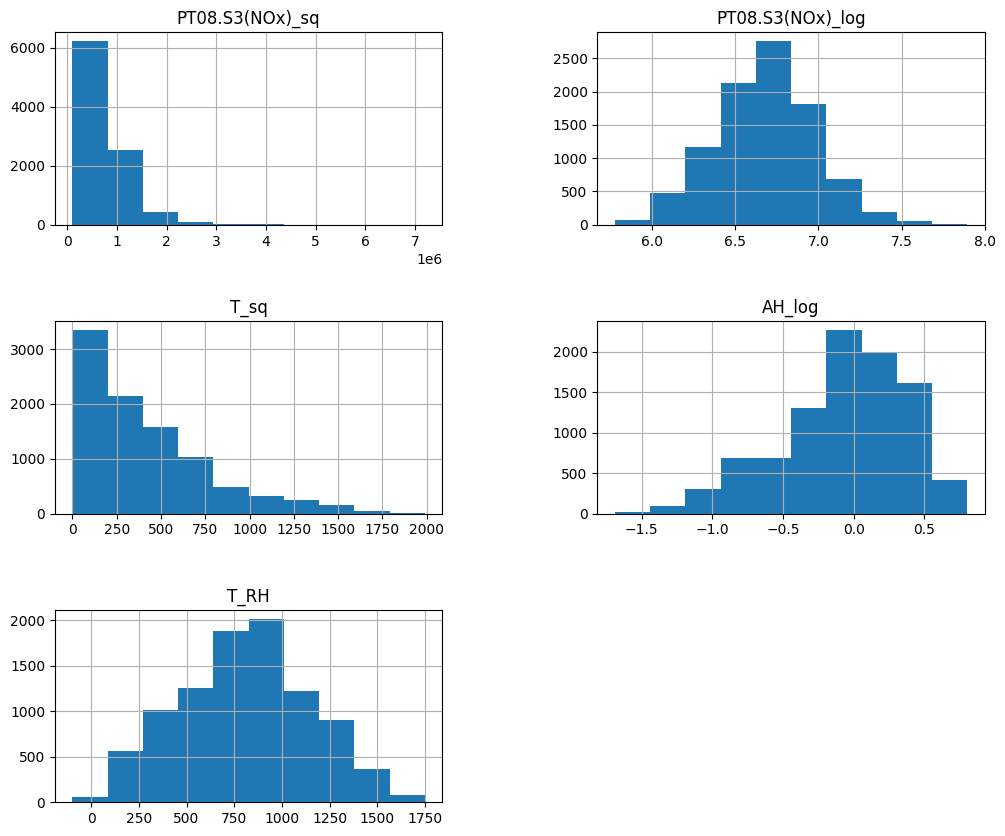

In [35]:
X.hist(figsize=(12, 10))
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()